In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Parameters
img_size = 64
batch_size = 32
base_dir = r"C:/Users/91636/Downloads/malaria dataset/cell_images/cell_images"

# Data augmentation and preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# Model architecture
model = Sequential([
    Input(shape=(img_size, img_size, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


In [3]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)



C:\Users\91636\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 414s 596ms/step - accuracy: 0.7413 - loss: 0.7111 - val_accuracy: 0.8506 - val_loss: 0.3947
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 386s 561ms/step - accuracy: 0.9020 - loss: 0.2907 - val_accuracy: 0.6492 - val_loss: 0.5143
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 157s 228ms/step - accuracy: 0.9130 - loss: 0.2607 - val_accuracy: 0.9076 - val_loss: 0.2675
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 156s 226ms/step - accuracy: 0.9152 - loss: 0.2504 - val_accuracy: 0.8597 - val_loss: 0.3392
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 156s 227ms/step - accuracy: 0.9183 - loss: 0.2367 - val_accuracy: 0.9174 - val_loss: 0.2389
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 155s 224ms/step - accuracy: 0.9230 - loss: 0.2340 - val_accuracy: 0.9114 - val_loss: 0.2462
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 155s 226ms/step - accuracy: 0.9204 - loss: 0.2340 - val_accuracy: 0.9132 - val_loss: 0.2558
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 157s 227ms/step - accuracy: 0.9186 -

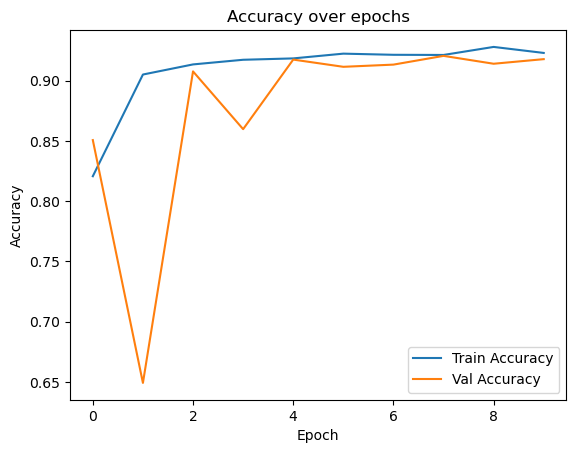

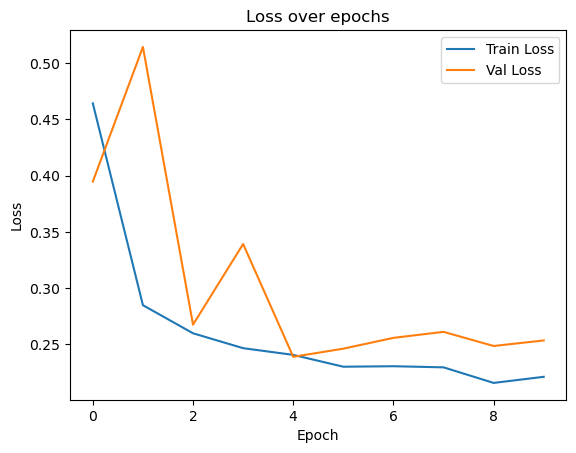

In [4]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

173/173 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step


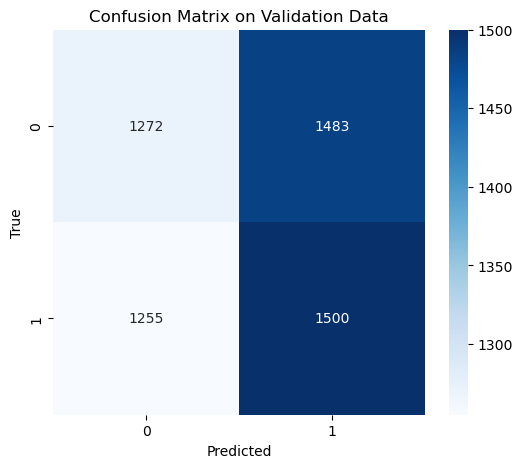

In [5]:
val_steps = val_data.samples // val_data.batch_size + 1
y_pred_probs = model.predict(val_data, steps=val_steps)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)
y_true = val_data.classes
y_pred = y_pred[:len(y_true)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Validation Data')
plt.show()


In [17]:
model.save("malaria_cnn_model.keras")



In [1]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array

# Load the trained model
model = load_model("malaria_cnn_model.keras")

# Define image size (must match the training input shape)
IMG_SIZE = 64

# Define prediction function
def classify_cell(img):
    # Resize and preprocess image
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Correct interpretation
    if prediction < 0.5:
        result = "Parasitized"
        confidence = 1 - prediction
    else:
        result = "Uninfected"
        confidence = prediction

    return f"{result} (Confidence: {confidence:.2%})"


# Define Gradio interface
interface = gr.Interface(
    fn=classify_cell,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Malaria Detection from Blood Smear Images",
    description="Upload a blood smear image to detect whether it is Parasitized or Uninfected."
)

# Launch the app
interface.launch()


C:\Users\91636\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
